# A/B Test Simulation by focusing on Power and Permutation and Z test. 

We are simulating an A/B test experiment for an online travel company (like Airbnb or Booking.com). There are two groups for the simulation : 

- **Control (UF = Upfront Fees)** → current system  
- **Treatment (BF = Back-End Fees)** → new system  

The goal is to demonstating  **Does switching to Back-End Fees increase the probability of purchase?**

The key assumptions in the simulation are :

- **Baseline purchase rate** = 7%  
- **Treatment effect** = +1.5 percentage points → 8.5%  
- Each website visit is **randomly assigned** to treatment or control  
- **Outcome** = purchase (1) or no purchase (0)  

In [ ]:
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
np.random.seed(seed=45)

In [23]:
def generate_data(n=1000, p_treated=0.5, p_purchase=0.07, treatment_effect=0.015):

    BF = np.random.choice([0, 1], size=n, p=[1 - p_treated, p_treated])

    purchase = []

    for i in range(n):
        if BF[i] == 0:
            purchase.append(np.random.choice([0, 1], p=[1 - p_purchase, p_purchase]))
        else:
            purchase.append(np.random.choice([0, 1], p=[1 - (p_purchase + treatment_effect), p_purchase + treatment_effect]))

    df = pd.DataFrame({
        "visit_ID": range(n),
        "BF": BF,
        "purchase": purchase
    })

    return df

df = generate_data()
df.head()

,visit_ID,BF,purchase
0,0,0,0
1,1,0,0
2,2,1,0
3,3,1,0
4,4,1,0


Based on the code above we can say that the **DGP(Data Generating Process)** can be written as:

$$
Y_i = \beta_0 + \beta_1 \cdot BF_i + u_i
$$

The regression is composed by variables: 

- $Y_i$ → purchase outcome (0 or 1)  
- $BF_i$ → treatment  
  - 0 = control (Upfront Fees)  
  - 1 = treatment (Back-End Fees)  
- $u_i$ → randomness (who buys and who doesn’t)  



In the code we have these numbers or values: 

- Control group → 7% purchase  
- Treatment group → 8.5% purchase  

So:

$$
\beta_0 = 0.07
$$

$$
\beta_1 = 0.015
$$

The form of the final regression is 

$$
Y_i = 0.07 + 0.015 \cdot BF_i + u_i
$$

---



#### We can assume the first case is the control group and it is like : 

$$
Y_i = 0.07 + 0.015 \cdot 0 + u_i = 0.07 + u_i
$$

Expected value:

$$
E[Y_i \mid BF = 0] = 0.07
$$

This matches the code:

np.random.choice([0, 1], p=[0.93, 0.07])



#### We can assume the second case is the control group and it is like : 

**From regression:**

$$
Y_i = 0.07 + 0.015 \cdot 1 + u_i = 0.085 + u_i
$$

**Expected value:**

$$
E[Y_i \mid BF = 1] = 0.085
$$


###  $P(Y=1 \mid BF=0) = 0.07$  simplay mean :
Across many similar people (or many repeated trials), about **7% will purchase**.
It means out of 100 people in the control group, just 70 of them on avg will buy and it does not mean that the control group do not buy at all or all people in treated group will buy. 

---

### One important point about the regression is that :

because it Binary or Bernouli we need to interpert and understand it clearly when it comes to individual vs group interpertaion. 

In Individual level for one person we have 

- buy → 1  
- don’t buy → 0  

But There is **no “7% outcome”** for one person.  But If we look at many people:

$$
\text{average purchase rate} \approx 0.07
$$

We can say this is where **0.07 comes from** . So we can say for one person outcome is 0 or 1 but for many people average ≈ 0.07. Because we don’t know exactly who buys, but we know:“on average, 7% buy”. So we model like :

$$
Y_i \sim \text{Bernoulli}(0.07)
$$

which means **0.07 is NOT an individual property** but it is It is: **population average** , **expected value**, **long-run frequency**

In [24]:
# the estimated average treatment effect

prob_purchase_UF = df[df["BF"] == 0]["purchase"].mean()  
prob_purchase_BF = df[df["BF"] == 1]["purchase"].mean()  

ATE = prob_purchase_BF - prob_purchase_UF
ATE

0.016662390146898458



$$
\widehat{ATE} = \bar{Y}_{\text{treated}} - \bar{Y}_{\text{control}}
$$

---

### In expectation (true effect)

$$
E[Y \mid BF = 1] - E[Y \mid BF = 0] = \text{True ATE}
$$

As a notice  what we have written here equals the **True ATE** only when **treatment is randomly assigned** ( no selection bias)

In this equation:

- **Control ≈ $\beta_0$**  
- **Treated − Control ≈ $\beta_1$**

Which means  **Back-End Fees increase the probability of purchase by 1.5 percentage points** or in a simpler words we can say:

-  **Control:** ~7% buy  : In control group just we see 7 percent of the people on avg bought 
-  **Treatment:** ~8.5% buy  : in treatment group 8.5 percent of the people on avg bought. 

So **Difference = +1.6%**  In other word estimated effect is 1.6 percentage point. If we assume we have 10,000 visitors, then:

- Control → ~700 purchases  
- Treatment → ~850 purchases  

**+150 extra purchases** is the tretament effect or $\beta_1$

The estimate is not exactly 0.015 because outcomes are **random** (0 or 1)   and sample size is **finite** (like 1000 observations). So we expect to see ATE like 0.013 , 0.017,  0.010 but typically **around 0.015**. 

As the sample size increases, the estimate gets **closer to 0.015** which rooted in Law of Large Numbers.

In a simpler word , because the data is limited like 500 obs for each group and data is random bianry Bernouli it is likely to have different number but it should not bee like 0.008 because it is a way far from true effect. So we can simulate it for myltiple times to see which values are seeing and if we see the number like 0.008, we will say it is a wring number. 


---

## Next Step of coding : 

In the next coding step, we will run a **permutation test**.

We simulate the **exchangeability assumption** by **shuffling treatment assignment**  assuming:
  - **50% → treatment**
  - **50% → control**

We will 

1. Create a new variable:

   **`shuffle_BF`**  and a new random allocation under the **sharp null hypothesis**

2. We will this shuffled data to compute:

   - Probability of purchase in **UF (control)**  
   - Probability of purchase in **BF (treatment)**  

3. Finally we will calculate:  **Estimated treatment effect under the sharp null**


The **key gaol** and point here is to see under the **sharp null**, treatment has **no effect**, so any observed difference comes purely from **random assignment**


In [25]:
df["shuffle_BF"] = np.random.choice([0, 1], p=[0.5, 0.5], size=len(df))
df

,visit_ID,BF,purchase,shuffle_BF
0,0,0,0,1
1,1,0,0,0
2,2,1,0,0
3,3,1,0,1
4,4,1,0,0
...,...,...,...,...
995,995,1,0,0
996,996,0,0,1
997,997,0,0,1
998,998,1,0,1


In [26]:
#  the simulated probability of purchase for UF and BF under shuffled assignment
prob_purchase_UF_shuffle = df[df["shuffle_BF"] == 0]["purchase"].mean()  
prob_purchase_BF_shuffle = df[df["shuffle_BF"] == 1]["purchase"].mean()  

ATE_shuffle = prob_purchase_BF_shuffle - prob_purchase_UF_shuffle

ATE_shuffle

-0.006828245816849404


---

##  Next step of coding(Repeating shuffling): 

We will **repeat the permutation process 100 times**, and for each iteration the we will Compute the **estimated treatment effect under the sharp null** and Store these estimates in a vector. In the next step we will do **visualization** in which We will plot a **histogram** of the estimated ATEs . This shows the **distribution of ATE under $H_0$**

Then from this distribution, we will examine:

- **Mean** of the ATE  
- **Minimum** value  
- **Maximum** value  

**the key idea**  is to find pout Under the **sharp null**, the ATE should be centered around **0** and any variation we see comes from **random chance only** . 

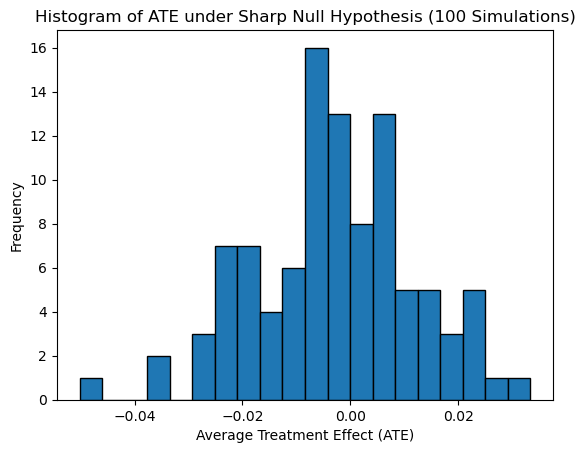

In [27]:

ate_null_distribution = []


for _ in range(100):
    
    df["shuffle_BF"] = np.random.choice([0, 1], p=[0.5, 0.5], size=len(df))
    
    
    prob_purchase_UF_shuffle = df[df["shuffle_BF"] == 0]["purchase"].mean()
    prob_purchase_BF_shuffle = df[df["shuffle_BF"] == 1]["purchase"].mean()
    
   
    ATE_shuffle = prob_purchase_BF_shuffle - prob_purchase_UF_shuffle
    
    
    ate_null_distribution.append(ATE_shuffle)


ate_null_distribution = np.array(ate_null_distribution)


plt.hist(ate_null_distribution, bins=20, edgecolor='black')
plt.title('Histogram of ATE under Sharp Null Hypothesis (100 Simulations)')
plt.xlabel('Average Treatment Effect (ATE)')
plt.ylabel('Frequency')
plt.show()

In [28]:
mean_ate = ate_null_distribution.mean()
min_ate = ate_null_distribution.min()
max_ate = ate_null_distribution.max()

mean_ate,min_ate,max_ate

(-0.002955967937455272, -0.05017533746457223, 0.03334654861019338)

The histogram shows the values of ATE_shuffle across those 100 fake experiments. This is your null distribution. It answers: **If BF really had no effect, what kind of ATE values would I usually see just from random assignment?**

Mean ATE = 0.002. This is very close to zero. That is good and expected.Because under the sharp null, treatment should have no effect on average, so shuffled ATEs should center around 0.


## Distribution of ATEs under the Null

### Mean of ATEs

$$
\text{mean} \approx 0
$$

Because  shuffling is **symmetric**  sometimes ATE is **positive**  sometimes ATE is **negative** but the important point is on average, they cancel out and **Expected values:** ≈ 0  or  0.0005 or -0.0008  

Min and Max are related to  **sampling noise** which can be a bit more because there is 1000 obs and to better undestand how it affects the result, it is better take a loomk at the equation :








## Next part of the code is Estimating P-value

We will estimate a **p-value** for a **two-sided permutation test** against the **sharp null hypothesis**.

The goal id to determine: Can we **reject the sharp null** at a **5% significance level**?

We will

- Compare the **observed ATE** to the distribution of ATEs under $H_0$  
- Compute the proportion of simulated ATEs that are **as extreme or more extreme** than the observed one  

This gives the **p-value**. 


- If **p-value < 0.05** → reject $H_0$  
- If **p-value ≥ 0.05** → fail to reject $H_0$  

And then we try to connection it to **confusion matrix**  like a classification problem:

- **Reject $H_0$ when it is false** →  Correct decision (True Positive)  
- **Reject $H_0$ when it is true** →  Type I error (False Positive)  
- **Do not reject $H_0$ when it is false** →  Type II error (False Negative)  
- **Do not reject $H_0$ when it is true** →  Correct decision (True Negative)  

 The **significance level (5%)** controls the probability of a **Type I error**  


As a last point we shuffled just for 100 times but we can and it is better to go for 1000 times.
1 shuffle → useless, 5 shuffles → still noisy, 100+ shuffles → better, 1000+ shuffles → very reliable



In [31]:
# the observed treatment effect from the original (non-shuffled) data
prob_purchase_UF = df[df["BF"] == 0]["purchase"].mean()  # UF (control group)
prob_purchase_BF = df[df["BF"] == 1]["purchase"].mean()  # BF (treatment group)
observed_ATE = prob_purchase_BF - prob_purchase_UF

# the two-sided p-value for the permutation test
# using the absolute values of the ATEs for a two-sided test
num_extreme = np.sum(np.abs(ate_null_distribution) >= np.abs(observed_ATE))
p_value = num_extreme / len(ate_null_distribution)

reject_null = p_value < 0.05

print(f"P-value: {p_value:.4f}")
print(f"Reject the sharp null at 5% significance level? {'Yes' if reject_null else 'No'}")

P-value: 0.3000
Reject the sharp null at 5% significance level? No



In above code we are asking among all shuffled ATEs, how many are **as large as the real ATE**? or  
**Out of all fake worlds (permutations), how often do we see an effect as extreme as the real one?**

We used abs() Because this is a **two-sided test**. So both:

- very **positive** values  
- very **negative** values  

 count as **extreme**

---

### P-value formula is : 


$$
p =
\frac{
\#\left( \left| \hat{\tau}_{\text{perm}} \right| \ge \left| \hat{\tau}_{\text{obs}} \right| \right)
}{
100
}
$$

or

$$
p\text{-value} =
\frac{\text{number of extreme shuffled ATEs}}
{\text{total number of shuffled ATEs}}
$$

---

We will reject the null if : **reject_null = p_value < 0.05 or in a simpler words we see at least more than 5 results out of 100 larger than observed ATE**

Since 0.2000 > 0.05, we fail to reject the null hypothesis. This means that there isn't enough evidence to conclude
that the treatment effect is statistically significant.

The observed effect (≈ 0.015) is not large enough relative to random noise to confidently rule out that it happened by chance.

The p-value indicates that the observed difference between the treatment and control groups is not statistically
significant at the 5% level. Therefore, we can't confidently say the treatment (Back-End Fees) has an effect on the
outcome (purchase probability).

It is True Negative because  the null hypothesis is true (no treatment effect), and we failed to reject it (p-value is greater 
than 0.05), this would be a true negative, meaning that we correctly concluded there is no effect.


Just as a short notice that saying **fail to reject H₀” does NOT mean “H₀ is definitely true**

It only means: **We don’t have enough evidence to reject it**


##  Next step of coding (Simulation Function)

In this step, we are going to wrap everything we have done into a **single function** building one function that performs the steps of the permutation test for us. 

In [32]:
def sim_perm_test(n, p_treated, p_purchase, treatment_effect, num_permutations=1000):

    df = generate_data(n, p_treated, p_purchase, treatment_effect)

    prob_purchase_UF = df[df["BF"] == 0]["purchase"].mean()
    prob_purchase_BF = df[df["BF"] == 1]["purchase"].mean()
    observed_ATE = prob_purchase_BF - prob_purchase_UF

    ate_null_distribution = []

    for _ in range(num_permutations):
        shuffled_BF = np.random.permutation(df["BF"])

        prob_purchase_UF_shuffle = df.loc[shuffled_BF == 0, "purchase"].mean()
        prob_purchase_BF_shuffle = df.loc[shuffled_BF == 1, "purchase"].mean()
        ATE_shuffle = prob_purchase_BF_shuffle - prob_purchase_UF_shuffle
        ate_null_distribution.append(ATE_shuffle)

    ate_null_distribution = np.array(ate_null_distribution)
    num_extreme = np.sum(np.abs(ate_null_distribution) >= np.abs(observed_ATE))
    p_value = num_extreme / len(ate_null_distribution)

    return p_value


p_value_test = sim_perm_test(n=1000, p_treated=0.5, p_purchase=0.07, treatment_effect=0.015)
print(f"Estimated p-value: {p_value_test:.4f}")

Estimated p-value: 0.2250


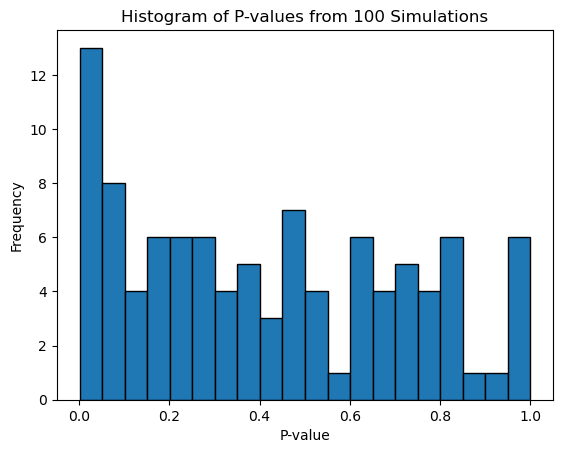

Percentage of times the null hypothesis was rejected at a 5% significance level: 12.00%


In [34]:
# Runnig sim_perm_test 100 times and storing the p-values
p_values = [sim_perm_test(n=1000, p_treated=0.5, p_purchase=0.07, treatment_effect=0.015) for _ in range(100)]


plt.hist(p_values, bins=20, edgecolor='black')
plt.title('Histogram of P-values from 100 Simulations')
plt.xlabel('P-value')
plt.ylabel('Frequency')
plt.show()

# Calculating the percentage of times we reject the null hypothesis at a 5% significance level
reject_null_count = sum(1 for p in p_values if p < 0.05)
reject_percentage = (reject_null_count / len(p_values)) * 100

print(f"Percentage of times the null hypothesis was rejected at a 5% significance level: {reject_percentage:.2f}%")

The histogram shows the distribution of p-values from 100 simulated experiments; most p-values are relatively large, indicating weak evidence against the null.

Only about 12% of simulations produced p-values below 0.05, meaning the test rejected the null in 12% of cases.
This implies low statistical power (~12%), so the experiment often fails to detect the true (but small) treatment effect.


## Next step of coding (Statistical Power for Different Sample Sizes)

Now we will repeat the process for the following sample sizes:

$$
n = [100,\ 1000,\ 2000,\ 5000,\ 10000,\ 25000]
$$

---

### In this simulation:

- we will Repeat the simulation for each sample size  
- then Calculate the **statistical power** for each value of $n$  
- then Create a graph with:
  - **sample size** on the x-axis  
  - **statistical power** on the y-axis  


Finally we will see among these sample sizes: **Which is the first sample size that surpasses 80% power?**

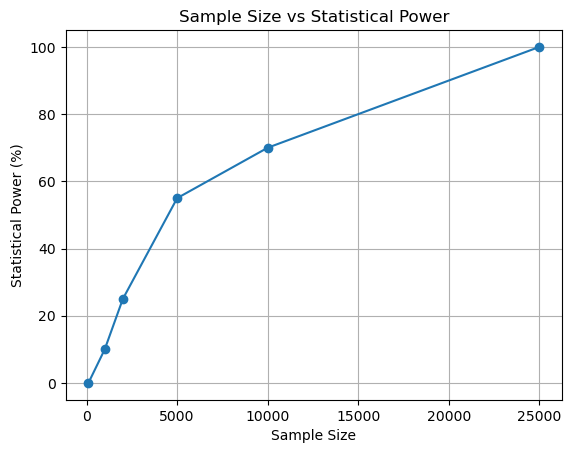

Power Results: [0.0, 10.0, 25.0, 55.00000000000001, 70.0, 100.0]
First Sample Size that surpasses 80% power: 25000


In [41]:
# the different sample sizes to test
sample_sizes = [100, 1000, 2000, 5000, 10000, 25000]
power_results = []

# Runnig sim_perm_test 20 times for each sample size to optimize the time
for n in sample_sizes:
    p_values = [sim_perm_test(n=n, p_treated=0.5, p_purchase=0.07, treatment_effect=0.015) for _ in range(20)]
    reject_null_count = sum(1 for p in p_values if p < 0.05)
    power = (reject_null_count / len(p_values)) * 100
    power_results.append(power)

plt.plot(sample_sizes, power_results, marker='o')
plt.title('Sample Size vs Statistical Power')
plt.xlabel('Sample Size')
plt.ylabel('Statistical Power (%)')
plt.grid(True)
plt.show()

# the first sample size that surpasses 80% power
first_above_80 = next((size for size, power in zip(sample_sizes, power_results) if power > 80), None)

print(f"Power Results: {power_results}")
print(f"First Sample Size that surpasses 80% power: {first_above_80}")


This graph is a clear picture of the **Effect of Sample Size on Power** so **as sample size increases, statistical power increases** . Because:

- Larger $n$ → **lower variance**  
- Noise **decreases**  
- Signal (0.015) becomes **easier to detect**  


### Key relationship

$$
\text{Signal-to-noise ratio} \uparrow \;\Rightarrow\; \text{Power} \uparrow
$$

As a final point we can say  with same effect size , less randomness, clearer difference between treatment and control  the  detection becomes **more reliable** . 



## The next step of coding is about  Minimum Detectable Effect Size (MDE)

Now we keep the **sample size fixed at $n = 1000$**, and vary the **effect size**.

We will:

- Create a range of effect sizes from **1pp to 8pp**  
- Increase by **0.5 percentage points (pp)** each step  


Goal here is to find the **minimum detectable effect size (MDE)** such that:

- **Statistical power ≥ 80%**  
- **Significance level = 5%** (95% confidence level)  

The intuition behind this simulation is finding MDE(Minimum Detectable Effect) or **“What is the smallest effect we can reliably detect with this sample size?”**

We expect to see:

- Smaller effects → harder to detect  
- Larger effects → easier to detect 

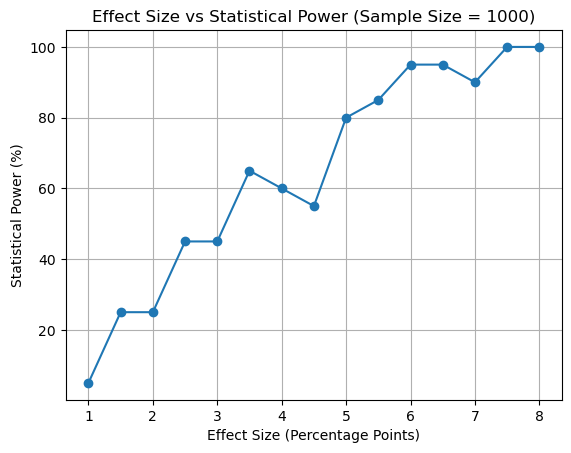

Power Results: [5.0, 25.0, 25.0, 45.0, 45.0, 65.0, 60.0, 55.00000000000001, 80.0, 85.0, 95.0, 95.0, 90.0, 100.0, 100.0]
Minimal Detectable Effect Size (at 80% power): 5.50pp


In [36]:
#  the range of effect sizes to test from 1pp to 8pp by increments of 0.5pp 
effect_sizes = np.arange(0.01, 0.081, 0.005)
power_results = []

n = 1000

# Running sim_perm_test 20 times for each effect size to calculate the power
for effect in effect_sizes:
    p_values = [sim_perm_test(n=n, p_treated=0.5, p_purchase=0.07, treatment_effect=effect) for _ in range(20)]
    reject_null_count = sum(1 for p in p_values if p < 0.05)
    power = (reject_null_count / len(p_values)) * 100
    power_results.append(power)


plt.plot(effect_sizes * 100, power_results, marker='o')  
plt.title('Effect Size vs Statistical Power (Sample Size = 1000)')
plt.xlabel('Effect Size (Percentage Points)')
plt.ylabel('Statistical Power (%)')
plt.grid(True)
plt.show()

#  the minimal detectable effect size that surpasses 80% power
min_detectable_effect = next((effect for effect, power in zip(effect_sizes, power_results) if power > 80), None)

print(f"Power Results: {power_results}")
if min_detectable_effect:
    print(f"Minimal Detectable Effect Size (at 80% power): {min_detectable_effect * 100:.2f}pp")
else:
    print("No effect size returned 80% power.")

As we can see holding sample size fixed at 1000 and varying the treatment effect from 1pp to 8pp, statistical power increases as the effect size increases. The smallest effect size that achieves at least 80% power is approximately 5.5 percentage points, so the minimum detectable effect (MDE) is about 5.5pp.

Although the relationship between effect size and statistical power should be increasing, the graph shows some fluctuations due to simulation noise. Since power is estimated using a finite number of repetitions, random variation can cause small deviations. Increasing the number of simulations would produce a smoother curve.



# Next step of coding : Proportion Z-test

Now, instead of a **permutation test**, we will use a **Z-test (proportion test)** to check whether the observed effect is real.

The goal here is to test whether the **Average Treatment Effect (ATE)** is statistically different from 0

$$
H_0: \text{ATE} = 0
$$

$$
H_1: \text{ATE} \neq 0
$$

We will code for estimating the **average treatment effect (ATE)**:

$$
\widehat{ATE} = \bar{Y}_{\text{treated}} - \bar{Y}_{\text{control}}
$$

- Compute:
  - **Z-statistic**
  - **p-value**

- If **p-value < 0.05** → reject $H_0$  
- If **p-value ≥ 0.05** → fail to reject $H_0$  

We are asking: **“Is the observed difference large enough that it is unlikely to be due to random chance?”**

In [37]:
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.power import zt_ind_solve_power
np.random.seed(seed=45)
df = generate_data (n=1000,  p_treated = 0.5, p_purchase = 0.07, treatment_effect = 0.015 )

In [38]:
#  the Average Treatment Effect
n_control = df[df["BF"] == 0].shape[0]
n_treatment = df[df["BF"] == 1].shape[0]
success_control = df[df["BF"] == 0]["purchase"].sum()
success_treatment = df[df["BF"] == 1]["purchase"].sum()

#  the proportions for control and treatment groups
prop_control = success_control / n_control
prop_treatment = success_treatment / n_treatment
ATE = prop_treatment - prop_control

#  Performing a proportions z-test for the hypothesis that ATE = 0
count = np.array([success_treatment, success_control])
nobs = np.array([n_treatment, n_control])
z_stat, p_value = proportions_ztest(count, nobs)

# Checking if the effect size is statistically significant at the 95% confidence level
significant = p_value < 0.05

print(f"Average Treatment Effect (ATE): {ATE:.4f}")
print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Is the effect size statistically significant at a 95% confidence level? {'Yes' if significant else 'No'}")

Average Treatment Effect (ATE): 0.0111
Z-statistic: 0.6667
P-value: 0.5050
Is the effect size statistically significant at a 95% confidence level? No


The estimated average treatment effect is approximately 0.011, meaning Back-End Fees increase purchase probability by about 1.1 percentage points. The two-sample proportion z-test gives a test statistic of about 0.7 and a p-value around 0.5. Since the p-value is greater than 0.05, the effect is not statistically significant at the 95% confidence level.



Before, we tested the treatment effect using a **permutation test**. Now, we test the same effect using a **proportion Z-test**.

Sometime we use Z-test because  Z-test uses **normal approximation** , Works well when sample size is **large** , and it is faster alternative to permutation test. More importantly because the outcome is **binary**:

- purchase = 1 → success  
- purchase = 0 → no success  

So we compare **two proportions**:

- purchase rate in **control (UF)**  
- purchase rate in **treatment (BF)**  



# Next step of the code:  Power calculation

- We will Calculate the statistical power of this experiment when population = 1000 at a 5% significance level, given the data generating process .

- We will Calculate the minimum population size in the experiment to achieve 80% power at a 5% significance level.

In Other word we will answer this questions:


- 1-If total population = 1000, what is the power? (This is asking question about Power)
- 2-How many total users do I need to get 80% power?(asks the reverse question) ( this is asking question about Required sample size)

---

- Part 1 → Given sample size → find power
- Part 2 → Given power → find sample size


In [39]:
n_total = 1000
p_baseline = 0.07  
treatment_effect = 0.015  


p_control = p_baseline
p_treatment = p_baseline + treatment_effect

# the standardized effect size
pooled_prob = (p_control + p_treatment) / 2
std_dev = np.sqrt(pooled_prob * (1 - pooled_prob))
effect_size = (p_treatment - p_control) / std_dev


power = zt_ind_solve_power(effect_size=effect_size, nobs1=n_total / 2, alpha=0.05, power=None, ratio=1, alternative='two-sided')


required_sample_size_per_group = zt_ind_solve_power(effect_size=effect_size, alpha=0.05, power=0.80, ratio=1, alternative='two-sided')


total_sample_size = required_sample_size_per_group * 2

print(f"Statistical Power (Population Size = 1000): {power:.4f}")
print(f"Minimum Population Size for 80% Power: {int(total_sample_size)}")

Statistical Power (Population Size = 1000): 0.1439
Minimum Population Size for 80% Power: 9975



- p_control = 0.07
- p_treatment = 0.085

Raw effect or difference  = 0.085−0.07=0.015. Then we convert that raw difference into a standardized effect size:
    
-  Pooled probability

$$
\hat{p} = \frac{p_{\text{control}} + p_{\text{treatment}}}{2}
$$

---

-  Standard deviation(This uses the Bernoulli standard deviation formula)

$$
\sigma = \sqrt{\hat{p}(1 - \hat{p})}
$$

---

- Effect size (standardized)

$$
\text{Effect Size} = \frac{p_{\text{treatment}} - p_{\text{control}}}{\sigma}
$$




---

###  Effect Size (Standardized)

$$
\text{Effect Size} =
\frac{p_{\text{treat}} - p_{\text{control}}}{\sqrt{p(1 - p)}}
$$


### Where:

$$
p = \frac{p_{\text{control}} + p_{\text{treat}}}{2}
$$


- Numerator → difference (signal)
- Denominator → variability (noise)
- Effect size → how strong the signal is relative to noise






---

# In Part 1 we are looking for probability of detecting the effect

$$
\text{Power} = P(\text{Reject } H_0 \mid \text{true effect exists})
$$

$$
\text{Power} = f(\text{effect size},\ n,\ \alpha)
$$

 “If I run this experiment with **1000 people**, how often will I succeed?”

---

## In Part 2, we are looking for  Sample Size (Reverse Problem)

Instead of:

$$
\text{Power} = f(n)
$$

we solve:

$$
n = f(\text{Power})
$$

👉 Find $n$ such that:

$$
\text{Power} = 0.80
$$

 “How many people do I need so I succeed **80% of the time**?”

---

We can say Part 1 is for **Evaluation** (given $n$, what is power?) and part 2 for  **Design** (given desired power, what is $n$?)  

But as a short notice we do not know the true effect but we must assume an effect size to do both parts.

Power=P(detect effect∣effect exists)





## Next part of the code : Proportion in Treatment and Control

Now we will change how the total population is split between the **treatment** and **control** groups.


We are going to change the number of population in control and treatment. We will calculate the power that would 
come from distributing that population 10 percent to treatment and 90 percent to control.Then repeat, adding 10 percent
to treatment and subtracting 10 percent from control, until we have 90 percent in treatment and 10 percent in control.

Then we will create a plot with proportion in treatment on the x-axis and statitial power on the y-axis.

In the final section we will find out what split between treatment and control maximizes statistical power?


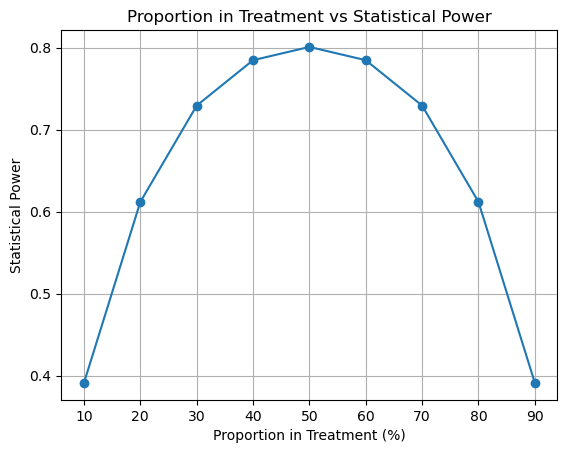

Statistical Power Values: [0.3910302576129529, 0.6118105575257945, 0.7293460753484963, 0.7847487568933904, 0.8009454085974893, 0.7847487568933904, 0.7293460753484962, 0.6118105575257945, 0.39103025761295285]
Best Split (Treatment %): 50.00%


In [40]:
rounded_population = 10000  # from the previous code we got it. 

p_baseline = 0.07  
treatment_effect = 0.015  
pooled_prob = (p_baseline + (p_baseline + treatment_effect)) / 2
std_dev = np.sqrt(pooled_prob * (1 - pooled_prob))
effect_size = treatment_effect / std_dev


treatment_percentages = np.arange(0.1, 1.0, 0.1)
power_values = []


for percent_treatment in treatment_percentages:
    n_treatment = rounded_population * percent_treatment
    n_control = rounded_population * (1 - percent_treatment)
    
    # the ratio for the zt_ind_solve_power function
    ratio = n_control / n_treatment
    
    
    power = zt_ind_solve_power(effect_size=effect_size, nobs1=n_treatment, alpha=0.05, power=None, ratio=ratio, alternative='two-sided')
    power_values.append(power)


plt.plot(treatment_percentages * 100, power_values, marker='o')
plt.title('Proportion in Treatment vs Statistical Power')
plt.xlabel('Proportion in Treatment (%)')
plt.ylabel('Statistical Power')
plt.grid(True)
plt.show()


max_power_index = np.argmax(power_values)
best_split_treatment = treatment_percentages[max_power_index] * 100


print(f"Statistical Power Values: {power_values}")
print(f"Best Split (Treatment %): {best_split_treatment:.2f}%")

As the graph is showing The split that maximizes statistical power is 50% treatment and 50% control.
The graph to rises as it move toward 50%, and then fall again after 50%. So the curve should look roughly like an upside-down U.
Because:

- power is lower when one group is too small
- power is highest when groups are balanced

### As a short note at the end:
    
We use power in the early phase to design the experiment, and then we use a **z-test** or **permutation test** at the end to evaluate the results. The z-test and permutation test answer the same question, so we can use either.

Z-test does NOT replace power neither Z-test replace permutation test conceptually.

- Power analysis ask **Can I detect the effect if it exists?” This helps us to choose correct sample size and design experiment**

- Z-test asks **Is the effect I observed statistically significant?** by giving p-value and decision (reject or not)

-  Permutation test (same goal as z-test)  and asks **Is the effect real or random?** Just a different method (simulation instead of formula)

- The task of Power is answering question like **Can my microscope detect bacteria?**
- The task of Z-test / permutation test is answering **Did I actually see bacteria?** 



